In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

df = pd.read_csv('../data/raw/rice.csv')
print(df.shape)
df.head()


(3810, 8)


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


In [28]:
df['Class_encoded'] = df['Class'].astype('category').cat.codes


In [29]:
# Train/test split (same fixed split used by every member's model, for fair comparison)
X = df.drop(columns=['Class_encoded']).values
y = df['Class_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Further split a validation set out of the training data (for Keras' validation_data)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)
print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


Train: (2590, 8)  Val: (458, 8)  Test: (762, 8)


In [30]:
# Hyperparameter tuning / model varieties
def build_model(hidden_layers, dropout, learning_rate):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    for units in hidden_layers:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Three varieties: (name, hidden_layers, dropout, learning_rate, batch_size)
variants = [
    {'name': 'Small_1Layer',   'hidden_layers': [16],      'dropout': 0.1, 'lr': 0.01,  'batch_size': 32},
    {'name': 'Medium_2Layer',  'hidden_layers': [32, 16],  'dropout': 0.2, 'lr': 0.001, 'batch_size': 32},
    {'name': 'Wide_1Layer',    'hidden_layers': [64],      'dropout': 0.3, 'lr': 0.001, 'batch_size': 16},
]
for v in variants:
    print(v)


{'name': 'Small_1Layer', 'hidden_layers': [16], 'dropout': 0.1, 'lr': 0.01, 'batch_size': 32}
{'name': 'Medium_2Layer', 'hidden_layers': [32, 16], 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32}
{'name': 'Wide_1Layer', 'hidden_layers': [64], 'dropout': 0.3, 'lr': 0.001, 'batch_size': 16}


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target = 'Class_encoded'
X = df.drop(columns=['Class', 'Class_encoded'], errors='ignore')
y = df[target]

X_train, X_test_np, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)


scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_tr).astype('float32')
X_val_np   = scaler.transform(X_val).astype('float32')
X_test_np  = scaler.transform(X_test_np).astype('float32')

y_train_np = y_tr.to_numpy().astype('float32')
y_val_np   = y_val.to_numpy().astype('float32')
y_test_np  = y_test.to_numpy().astype('float32')

print(X_train_np.shape, X_val_np.shape, X_test_np.shape)

(2438, 7) (610, 7) (762, 7)


In [33]:
# Train all three varieties (with EarlyStopping to prevent overfitting)
histories = {}
trained_models = {}

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

for v in variants:
    print(f"\n=== Training variant: {v['name']} ===")
    
    model = build_model(v['hidden_layers'], v['dropout'], v['lr'])
    
   
    history = model.fit(
        X_train_np, y_train_np,
        validation_data=(X_val_np, y_val_np),
        epochs=100,
        batch_size=v['batch_size'],
        callbacks=[early_stop],
        verbose=0
    )
    
    histories[v['name']] = history
    trained_models[v['name']] = model
    
    stopped_epoch = len(history.history['loss'])
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"Stopped after {stopped_epoch} epochs | final val_accuracy={final_val_acc:.4f}")


=== Training variant: Small_1Layer ===
Stopped after 13 epochs | final val_accuracy=0.9328

=== Training variant: Medium_2Layer ===
Stopped after 46 epochs | final val_accuracy=0.9295

=== Training variant: Wide_1Layer ===
Stopped after 17 epochs | final val_accuracy=0.9311


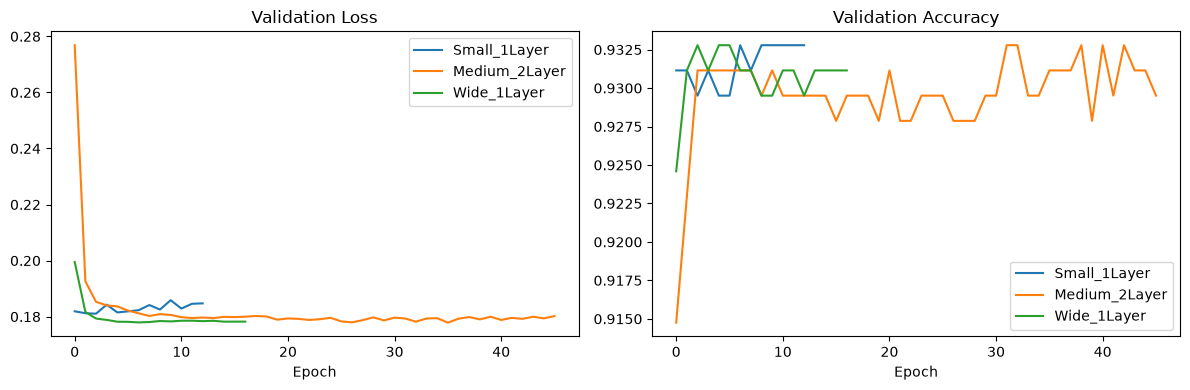

In [34]:
# Training curves — compare how each variety learns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, h in histories.items():
    axes[0].plot(h.history['val_loss'], label=name)
    axes[1].plot(h.history['val_accuracy'], label=name)

axes[0].set_title('Validation Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig('../results/eda_visualizations/mlp_variants_training_curves.png', dpi=150)
plt.show()


In [35]:
# Evaluate all three varieties on the held-out test set
variant_results = []

for v in variants:
    name = v['name']
    model = trained_models[name]
    y_prob = model.predict(X_test_np, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    variant_results.append({
        'variant': name,
        'hidden_layers': v['hidden_layers'],
        'dropout': v['dropout'],
        'learning_rate': v['lr'],
        'batch_size': v['batch_size'],
        'epochs_trained': len(histories[name].history['loss']),
        'test_accuracy': round(float(acc), 4),
        'test_precision': round(float(prec), 4),
        'test_recall': round(float(rec), 4),
        'test_f1': round(float(f1), 4),
    })

results_df = pd.DataFrame(variant_results)
results_df.sort_values('test_f1', ascending=False)


,variant,hidden_layers,dropout,learning_rate,batch_size,epochs_trained,test_accuracy,test_precision,test_recall,test_f1
2,Wide_1Layer,[64],0.3,0.001,16,17,0.9213,0.9292,0.9335,0.9314
0,Small_1Layer,[16],0.1,0.010,32,13,0.9186,0.9250,0.9335,0.9292
1,Medium_2Layer,"[32, 16]",0.2,0.001,32,46,0.9173,0.9191,0.9381,0.9285


Best variant: Wide_1Layer
              precision    recall  f1-score   support

      Cammeo       0.91      0.90      0.91       326
    Osmancik       0.93      0.93      0.93       436

    accuracy                           0.92       762
   macro avg       0.92      0.92      0.92       762
weighted avg       0.92      0.92      0.92       762



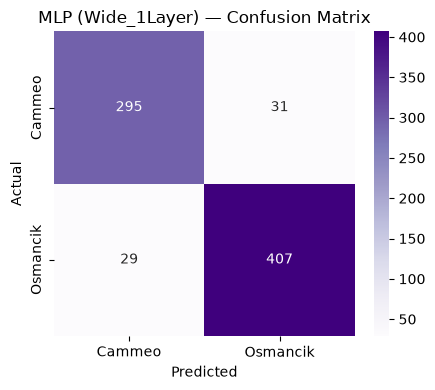

In [36]:
# Confusion matrix for the best-performing variety
best_variant_name = results_df.sort_values('test_f1', ascending=False).iloc[0]['variant']
best_model = trained_models[best_variant_name]

y_prob = best_model.predict(X_test_np, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(f"Best variant: {best_variant_name}")
print(classification_report(y_test, y_pred, target_names=['Cammeo', 'Osmancik']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Cammeo', 'Osmancik'], yticklabels=['Cammeo', 'Osmancik'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'MLP ({best_variant_name}) — Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/mlp_best_confusion_matrix.png', dpi=150)
plt.show()


In [25]:
os.makedirs('../results/logs', exist_ok=True)

best_row = results_df.sort_values('test_f1', ascending=False).iloc[0]
summary = {
    'member': 'IT25102603',
    'model': 'Neural Network (MLP - Keras/TensorFlow)',
    'best_params': {
        'hidden_layers': best_row['hidden_layers'],
        'dropout': best_row['dropout'],
        'learning_rate': best_row['learning_rate'],
        'batch_size': int(best_row['batch_size'])
    },
    'variants_compared': results_df.to_dict(orient='records'),
    'test_accuracy': best_row['test_accuracy'],
    'test_precision': best_row['test_precision'],
    'test_recall': best_row['test_recall'],
    'test_f1': best_row['test_f1'],
}

with open('../results/logs/Member6_MLP_DeepLearning_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))


{
  "member": "IT25102603",
  "model": "Neural Network (MLP - Keras/TensorFlow)",
  "best_params": {
    "hidden_layers": [
      16
    ],
    "dropout": 0.1,
    "learning_rate": 0.01,
    "batch_size": 32
  },
  "variants_compared": [
    {
      "variant": "Small_1Layer",
      "hidden_layers": [
        16
      ],
      "dropout": 0.1,
      "learning_rate": 0.01,
      "batch_size": 32,
      "epochs_trained": 12,
      "test_accuracy": 0.4278,
      "test_precision": 0.0,
      "test_recall": 0.0,
      "test_f1": 0.0
    },
    {
      "variant": "Medium_2Layer",
      "hidden_layers": [
        32,
        16
      ],
      "dropout": 0.2,
      "learning_rate": 0.001,
      "batch_size": 32,
      "epochs_trained": 34,
      "test_accuracy": 0.4278,
      "test_precision": 0.0,
      "test_recall": 0.0,
      "test_f1": 0.0
    },
    {
      "variant": "Wide_1Layer",
      "hidden_layers": [
        64
      ],
      "dropout": 0.3,
      "learning_rate": 0.001,
      "batc